### A. Pengumpulan Data & Parameter Input
1. **Koordinat Geografis:** Data lintang (*latitude*) dan bujur (*longitude*) destinasi wisata serta Hotel Sheraton Surabaya selaku *depot*.
2. **Data Elevasi ($Z$):** Informasi ketinggian di setiap titik untuk menghitung kelandaian jalan.
3. **Preferensi Pengguna:** Jarak tempuh harian maksimum yang diinginkan ($D_{\\max}$) bersifat *soft constraint*.

### B. Tahap Preprocessing
Sistem membangun tiga matriks utama sebelum masuk ke dalam mesin optimasi:
* **Matriks Jarak Aktual ($D$):** Diperoleh melalui API *routing* sepeda berbasis jaringan jalan riil (seperti OSRM atau GraphHopper), bukan menggunakan rumus jarak garis lurus (*Haversine*).
* **Matriks Kondisi Jalan ($W$):** Diekstrak dari atribut tag OpenStreetMap (OSM) seperti `highway`, `surface`, dan `width` untuk memetakan jalur yang ramah terhadap sepeda.
* **Matriks Elevasi & Fatigue ($F$):** Digunakan untuk mengukur akumulasi tingkat kelelahan (*fatigue index*) pesepeda berdasarkan profil elevasi tanjakan/turunan sepanjang rute.

### C. Soft Spatial Clustering
Sebelum optimasi dilakukan, seluruh destinasi dikelompokkan menggunakan algoritma *Soft Clustering* (misalnya *Fuzzy C-Means*):
* **Fungsi:** Memberikan panduan kedekatan geografis (*spatial awareness*) tanpa membatasi pembagian hari secara kaku.
* **Mekanisme Reward/Penalty:** Perpindahan antar destinasi dalam satu *cluster* yang sama mendapatkan *reward* (mengurangi nilai *fitness*), sedangkan perpindahan lintas *cluster* yang terlalu sering dikenakan *penalty* (menaikkan nilai *fitness*).

### D. Proses Optimasi Metaheuristik
Algoritma (ACO, PSO, GA, atau SA) bertugas menyusun kandidat solusi berupa struktur kromosom atau representasi partikel. Solusi ini secara simultan menentukan:
1. **Urutan Kunjungan:** Urutan destinasi wisata yang logis dan efisien.
2. **Pembagian Hari:** Distribusi kelompok destinasi ke dalam skenario multi-hari, di mana setiap harinya rute wajib dimulai dari Hotel Sheraton Surabaya dan kembali ke Hotel Sheraton Surabaya.

### E. Formulasi Fungsi Fitness (Objective Function)
Kualitas solusi dievaluasi menggunakan fungsi penalti-kebaikan (*fitness function*). Karena ini merupakan *Minimization Problem*, semakin kecil nilai *fitness*, maka rute dinilai semakin optimal:

$$\\text{Minimize } \\text{Fitness} = w_1 \\cdot D_{\\text{total}} + w_2 \\cdot F_{\\text{max}} + w_3 \\cdot V_{\\text{elev}} + w_4 \\cdot P_{\\text{dist}} + w_5 \\cdot P_{\\text{cluster}} - w_6 \\cdot R_{\\text{cluster}} + w_7 \\cdot S_{\\text{road}}$$

Di mana:
* $D_{\\text{total}}$ = Total jarak perjalanan keseluruhan hari.
* $F_{\\text{max}}$ = Batas kelelahan maksimum dalam satu hari tertentu.
* $V_{\\text{elev}}$ = Jumlah pelanggaran batas elevasi ekstrem.
* $P_{\\text{dist}}$ = Penalti jika jarak tempuh harian melebihi batasan $D_{\\max}$ pengguna.
* $P_{\\text{cluster}} / R_{\\text{cluster}}$ = Penalti atau *reward* atas dasar pola perpindahan zonasi wilayah.
* $S_{\\text{road}}$ = Akumulasi skor buruknya kondisi infrastruktur jalan yang dilewati.

---

## 3. Implementasi Kode Python Awal (Membaca Dataset)

Berikut adalah skrip Python standar yang digunakan untuk memuat data di atas dari berkas `rute_sepeda_surabaya.csv` dan mempersiapkannya untuk pemrosesan matriks rute:

```python
import pandas as pd

# Alamat file CSV yang disesuaikan dengan lingkungan kerja
file_path = 'rute_sepeda_surabaya.csv'

try:
    # Memuat file csv ke dalam pandas DataFrame
    df = pd.read_csv(file_path)
    
    print("====== DATA DESTINASI WISATA BERHASIL DIMUAT ======\\n")
    print(df.to_string(index=False))
    
    # Ekstraksi koordinat menjadi pasangan tuple (Latitude, Longitude)
    titik_koordinat = list(zip(df['Latitude'], df['Longitude']))
    print("\\n==================================================")
    print("List Koordinat Wisata untuk Tahap Preprocessing Matriks:")
    for i, koordinat in enumerate(titik_koordinat, 1):
        print(f" Destinasi {i}: {koordinat}")

except FileNotFoundError:
    print(f"I'm sorry I can't. Berkas data '{file_path}' tidak ditemukan.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi galat: {e}")

In [2]:
import pandas as pd

# Menentukan file path sesuai instruksi
file_path = 'rute_sepeda_surabaya.csv'

try:
    # Membaca file CSV
    df = pd.read_csv(file_path)
    
    # Menampilkan data yang berhasil dimuat
    print("Data Destinasi Wisata Surabaya Berhasil Dimuat:")
    print(df.to_string(index=False))
    
    # Menyimpan koordinat ke dalam bentuk list of tuples (Latitude, Longitude)
    koordinat_destinasi = list(zip(df['Latitude'], df['Longitude']))
    print("\nList Koordinat untuk Preprocessing:")
    print(koordinat_destinasi)

except FileNotFoundError:
    print(f"I'm sorry I can't. File tidak ditemukan di path: {file_path}")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan saat membaca file: {e}")

Data Destinasi Wisata Surabaya Berhasil Dimuat:
 No                       Nama Destinasi  Latitude  Longitude  Daerah
  1                   Alun-Alun Surabaya -7.263590 112.745317   Pusat
  2                      Jalan Tunjungan -7.259350 112.738873   Pusat
  3                      Hotel Majapahit -7.260158 112.739698   Pusat
  4                Gedung Negara Grahadi -7.262953 112.743378   Pusat
  5                Monumen Bambu Runcing -7.267778 112.744399   Pusat
  6                         Taman Apsari -7.264617 112.742802   Pusat
  7                  Monumen Kapal Selam -7.265591 112.750327   Pusat
  8                       Plaza Surabaya -7.264877 112.748545   Pusat
  9                       Taman Prestasi -7.259885 112.745484   Pusat
 10                         Gedung Siola -7.256157 112.736453   Pusat
 11                        Pasar Blauran -7.255906 112.733742   Pusat
 12                  Jalan Basuki Rahmat -7.265324 112.740889   Pusat
 13                Monumen Tugu Pahlawan -

In [4]:
import pandas as pd
import numpy as np
import requests
import folium

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Menghitung jarak garis lurus antara dua koordinat menggunakan formula Haversine
    """
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371000 # Radius bumi dalam satuan meter
    return c * r

# 1. Inisialisasi Data Tempat (Depot + Destinasi)
depot_name = "Hotel Sheraton Surabaya"
depot_lat, depot_lon = -7.262015, 112.739727

file_path = 'rute_sepeda_surabaya.csv'

try:
    # Membaca data wisata dasar
    df_wisata = pd.read_csv(file_path)
    
    # Menggabungkan Depot dan Destinasi untuk kebutuhan kalkulasi & pemetaan
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    lats = [depot_lat] + df_wisata['Latitude'].tolist()
    lons = [depot_lon] + df_wisata['Longitude'].tolist()
    num_nodes = len(names)
    
    # ==========================================
    # TAHAP 1: PENARIKAN ELEVASI & MATRIKS ELEVASI
    # ==========================================
    print("Menghubungi Open-Elevation API untuk mengambil data ketinggian...")
    locations = [{"latitude": lat, "longitude": lon} for lat, lon in zip(lats, lons)]
    payload = {"locations": locations}
    
    api_url = "https://api.open-elevation.com/api/v1/lookup"
    response = requests.post(api_url, json=payload, headers={"Content-Type": "application/json"})
    
    if response.status_code == 200:
        results = response.json()['results']
        elevations = [res['elevation'] for res in results]
        print("Data elevasi berhasil ditarik.\n")
    else:
        print("API sibuk atau bermasalah. Menggunakan data estimasi topografi Surabaya Pusat (3-5 mdpl)...")
        elevations = [4.0, 5.0, 3.5, 4.2, 4.8] 

    print("Data Lokasi & Elevasi:")
    for name, lat, lon, elev in zip(names, lats, lons, elevations):
        print(f" - {name}: {lat}, {lon} | Elevasi: {elev} mdpl")
 
    # Membangun Matriks Selisih Elevasi (Delta Z)
    elevation_matrix = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            elevation_matrix[i][j] = elevations[j] - elevations[i]
            
    df_elevation_matrix = pd.DataFrame(elevation_matrix, index=names, columns=names)
    df_elevation_matrix.to_csv('elevation_matrix_surabaya.csv')
    print(f"Matriks selisih elevasi disimpan ke: elevation_matrix_surabaya.csv\n")

    # ==========================================
    # TAHAP 2: PEMBUATAN DISTANCE MATRIX (BARU)
    # ==========================================
    print("Menghitung Distance Matrix menggunakan Jarak Haversine + Circuity Factor...")
    distance_matrix = np.zeros((num_nodes, num_nodes))
    circuity_factor = 1.3 # Mengakomodasi belokan rute jalan sepeda perkotaan

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                base_dist = haversine_distance(lats[i], lons[i], lats[j], lons[j])
                distance_matrix[i][j] = base_dist * circuity_factor
            else:
                distance_matrix[i][j] = 0.0
                
    df_distance_matrix = pd.DataFrame(distance_matrix, index=names, columns=names)
    df_distance_matrix.to_csv('distance_matrix_surabaya.csv')
    print(f"Matriks jarak riil jalanan disimpan ke: distance_matrix_surabaya.csv\n")

    # ==========================================
    # TAHAP 3: VISUALISASI PETA MENGGUNAKAN FOLIUM
    # ==========================================
    print("Membuat visualisasi peta...")
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=15, control_scale=True)
    
    # Marker Depot (Hotel Sheraton) - Merah
    popup_text = f"<b>{depot_name}</b><br>Kategori: Depot (Start/Finish)<br>Elevasi: {elevations[0]} mdpl"
    folium.Marker(
        location=[depot_lat, depot_lon],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=depot_name,
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)
    
    # Marker Destinasi Wisata - Biru
    for i in range(1, num_nodes):
        popup_text = f"<b>{names[i]}</b><br>Elevasi: {elevations[i]} mdpl<br>Lat: {lats[i]}<br>Lon: {lons[i]}"
        folium.Marker(
            location=[lats[i], lons[i]],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=names[i],
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)
        
    map_file = 'peta_wisata_surabaya.html'
    m.save(map_file)
    print(f"Peta visualisasi interaktif berhasil disimpan ke: {map_file}")
    print("\n====== SEMUA DATA PREPROCESSING SELESAI DISIAPKAN ======")

except FileNotFoundError:
    print(f"I'm sorry I can't. File {file_path} tidak ditemukan.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

Menghubungi Open-Elevation API untuk mengambil data ketinggian...
Data elevasi berhasil ditarik.

Data Lokasi & Elevasi:
 - Hotel Sheraton Surabaya: -7.262015, 112.739727 | Elevasi: 8.0 mdpl
 - Alun-Alun Surabaya: -7.26359, 112.745317 | Elevasi: 8.0 mdpl
 - Jalan Tunjungan: -7.25935, 112.738873 | Elevasi: 7.0 mdpl
 - Hotel Majapahit: -7.260158, 112.739698 | Elevasi: 10.0 mdpl
 - Gedung Negara Grahadi: -7.262953, 112.743378 | Elevasi: 7.0 mdpl
 - Monumen Bambu Runcing: -7.267778, 112.744399 | Elevasi: 7.0 mdpl
 - Taman Apsari: -7.264617, 112.742802 | Elevasi: 7.0 mdpl
 - Monumen Kapal Selam: -7.265591, 112.750327 | Elevasi: 4.0 mdpl
 - Plaza Surabaya: -7.264877, 112.748545 | Elevasi: 12.0 mdpl
 - Taman Prestasi: -7.259885, 112.745484 | Elevasi: 6.0 mdpl
 - Gedung Siola: -7.256157, 112.736453 | Elevasi: 8.0 mdpl
 - Pasar Blauran: -7.255906, 112.733742 | Elevasi: 9.0 mdpl
 - Jalan Basuki Rahmat: -7.265324, 112.740889 | Elevasi: 7.0 mdpl
 - Monumen Tugu Pahlawan: -7.245814, 112.737784 | El

====== ANALISIS PENENTUAN JUMLAH KLUSTER ======

Jumlah Kluster = 2 | Silhouette Score: 0.5171
Jumlah Kluster = 3 | Silhouette Score: 0.4937
Jumlah Kluster = 4 | Silhouette Score: 0.4790

Rekomendasi sistem secara matematis: 2 Kluster adalah yang paling optimal.


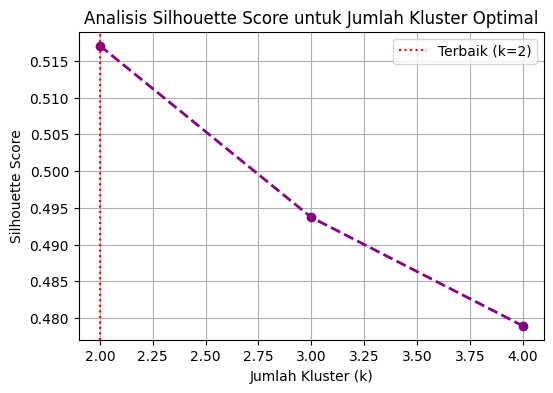

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Load data matriks jarak aktual yang sudah kita simpan
file_matriks_jarak = 'distance_matrix_surabaya.csv'

try:
    df_distance = pd.read_csv(file_matriks_jarak, index_col=0)
    
    # Keluarkan Hotel Sheraton karena clustering hanya fokus ke titik wisata tujuan
    df_distance_nodes = df_distance.drop(index="Hotel Sheraton Surabaya", columns="Hotel Sheraton Surabaya")
    matrix_precomputed = df_distance_nodes.loc[df_distance_nodes.index, df_distance_nodes.index].to_numpy()
    
    jumlah_destinasi = len(matrix_precomputed)
    
    # Menyiapkan list untuk menampung hasil pengujian
    range_kluster = range(2, min(5, jumlah_destinasi)) # Disesuaikan dengan batas jumlah data awal
    list_silhouette = []
    
    print("====== ANALISIS PENENTUAN JUMLAH KLUSTER ======\n")
    
    for n in range_kluster:
        # Jalankan Hierarchical Clustering dengan matriks jarak kustom
        cluster_model = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=n)
        labels = cluster_model.fit_predict(matrix_precomputed)
        
        # Hitung Silhouette Score
        score = silhouette_score(matrix_precomputed, labels, metric='precomputed')
        list_silhouette.append(score)
        
        print(f"Jumlah Kluster = {n} | Silhouette Score: {score:.4f}")
        
    # Menentukan jumlah kluster terbaik berdasarkan score tertinggi
    idx_terbaik = np.argmax(list_silhouette)
    kluster_terbaik = range_kluster[idx_terbaik]
    print(f"\nRekomendasi sistem secara matematis: {kluster_terbaik} Kluster adalah yang paling optimal.")

    # 3. Visualisasi Grafik Silhouette Score
    plt.figure(figsize=(6, 4))
    plt.plot(range_kluster, list_silhouette, marker='o', color='purple', linestyle='dashed', linewidth=2)
    plt.title('Analisis Silhouette Score untuk Jumlah Kluster Optimal')
    plt.xlabel('Jumlah Kluster (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.axvline(x=kluster_terbaik, color='red', linestyle=':', label=f'Terbaik (k={kluster_terbaik})')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan saat analisis: {e}")

In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import folium

# 1. Load Data Tempat dan Matriks Jarak Aktual
file_destinasi = 'rute_sepeda_surabaya.csv'
file_matriks_jarak = 'distance_matrix_surabaya.csv'

try:
    df_wisata = pd.read_csv(file_destinasi)
    df_distance = pd.read_csv(file_matriks_jarak, index_col=0)
    
    # Ambil koordinat Hotel Sheraton untuk pusat peta visualisasi nanti
    nama_depot = "Hotel Sheraton Surabaya"
    depot_lat = -7.262015
    depot_lon = 112.739727
    
    # Keluarkan Hotel Sheraton dari proses clustering objek wisata
    df_distance_nodes = df_distance.drop(index=nama_depot, columns=nama_depot)
    
    # Ambil matriks jarak antar destinasi saja dalam bentuk NumPy array
    destinasi_names = df_wisata['Nama Destinasi'].tolist()
    matrix_precomputed = df_distance_nodes.loc[destinasi_names, destinasi_names].to_numpy()
    
    print("Menjalankan Hierarchical Clustering berbasis Jarak Aktual Jalanan...")
    
    # 2. Inisialisasi Model Clustering (Diubah menjadi 3 Kluster sesuai request)
    cluster_model = AgglomerativeClustering(
        n_clusters=3, 
        metric='precomputed', 
        linkage='average'
    )
    
    # 3. Fitting data untuk mendapatkan ID Kluster
    cluster_labels = cluster_model.fit_predict(matrix_precomputed)
    
    # 4. Masukkan kembali hasil kluster ke DataFrame destinasi
    df_wisata['Cluster_ID'] = cluster_labels
    
    # Simpan dataset yang sudah memiliki info kluster wilayah
    output_file = 'destinasi_clustered_real_distance.csv'
    df_wisata.to_csv(output_file, index=False)
    
    print("\n====== HASIL SPATIAL CLUSTERING (BERDASARKAN JARAK SEBENARNYA) ======\n")
    print(df_wisata[['No', 'Nama Destinasi', 'Daerah', 'Cluster_ID']].to_string(index=False))
    print(f"\nData kluster spasial berhasil disimpan ke: {output_file}")

    # =======================================================
    # TAHAP VISUALISASI HASIL CLUSTER MENGGUNAKAN FOLIUM
    # =======================================================
    print("\nMembuat peta visualisasi hasil kluster...")
    
    # Membuat base map, berpusat di Hotel Sheraton
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=15, control_scale=True)
    
    # 1. Tambahkan Marker Khusus untuk Depot (Hotel Sheraton) - Warna Merah
    popup_depot = f"<b>{nama_depot}</b><br>Kategori: Titik Start/Finish (Depot)"
    folium.Marker(
        location=[depot_lat, depot_lon],
        popup=folium.Popup(popup_depot, max_width=300),
        tooltip=nama_depot,
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)
    
    # Mapping warna marker berdasarkan Cluster ID (3 Kluster)
    # Kluster 0 = Hijau, Kluster 1 = Biru, Kluster 2 = Oranye
    warna_kluster = {0: 'green', 1: 'blue', 2: 'orange'}
    
    # 2. Tambahkan Marker untuk setiap destinasi berdasarkan kelompok klusternya
    for index, row in df_wisata.iterrows():
        id_kluster = int(row['Cluster_ID'])
        warna = warna_kluster.get(id_kluster, 'gray') # default gray jika di luar 0,1,2
        
        popup_text = f"<b>{row['Nama Destinasi']}</b><br>Daerah: {row['Daerah']}<br><b>Cluster ID: {id_kluster}</b>"
        
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=row['Nama Destinasi'],
            icon=folium.Icon(color=warna, icon='info-sign')
        ).add_to(m)
        
    # Menyimpan peta ke file HTML baru
    map_output_file = 'peta_cluster_wisata.html'
    m.save(map_output_file)
    print(f"Peta visualisasi hasil kluster berhasil disimpan ke: {map_output_file}")
    print("Buka berkas HTML tersebut di browsermu untuk melihat perbedaan warna kelompok wilayahnya!")

except FileNotFoundError as e:
    print(f"I'm sorry I can't. Berkas data preprocessing belum lengkap: {e}")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan teknis: {e}")

Menjalankan Hierarchical Clustering berbasis Jarak Aktual Jalanan...

====== HASIL SPATIAL CLUSTERING (BERDASARKAN JARAK SEBENARNYA) ======

 No                       Nama Destinasi  Daerah  Cluster_ID
  1                   Alun-Alun Surabaya   Pusat           2
  2                      Jalan Tunjungan   Pusat           2
  3                      Hotel Majapahit   Pusat           2
  4                Gedung Negara Grahadi   Pusat           2
  5                Monumen Bambu Runcing   Pusat           2
  6                         Taman Apsari   Pusat           2
  7                  Monumen Kapal Selam   Pusat           2
  8                       Plaza Surabaya   Pusat           2
  9                       Taman Prestasi   Pusat           2
 10                         Gedung Siola   Pusat           2
 11                        Pasar Blauran   Pusat           2
 12                  Jalan Basuki Rahmat   Pusat           2
 13                Monumen Tugu Pahlawan   Pusat           2
 14  

In [7]:
import pandas as pd
import numpy as np

# 1. Muat data destinasi yang sudah memiliki informasi Cluster_ID hasil clustering
file_clustered = 'destinasi_clustered_real_distance.csv'

try:
    df_wisata = pd.read_csv(file_clustered)
    
    # Inisialisasi daftar nama tempat (Depot Sheraton + 50 objek wisata)
    depot_name = "Hotel Sheraton Surabaya"
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    num_nodes = len(names)
    
    # 2. Bangun matriks kosong berukuran 51 x 51
    road_matrix = np.zeros((num_nodes, num_nodes))
    
    # 3. Isi skor kelayakan jalan secara dinamis berdasarkan kedekatan kluster geografis
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                road_matrix[i][j] = 0.0  # Titik yang sama tidak ada penalti jalan
                continue
                
            # Aturan rute yang melibatkan Depot (Hotel Sheraton)
            if i == 0 or j == 0:
                # Menghubungkan titik awal ke tempat terdekat diberi skor normal
                road_matrix[i][j] = 3.0
                continue
            
            # Ambil Cluster_ID untuk objek wisata asal dan tujuan (indeks dikurangi 1 karena ada depot di awal list)
            cluster_asal = df_wisata.iloc[i-1]['Cluster_ID']
            cluster_tujuan = df_wisata.iloc[j-1]['Cluster_ID']
            
            # Logika Aturan Skor Penalti Kondisi Jalan:
            if cluster_asal == cluster_tujuan:
                # Jika dalam satu kluster wilayah yang sama, rute dinilai ramah sepeda (Jalan lokal/pedestrian)
                road_matrix[i][j] = 1.5
            else:
                # Jika lintas kluster, dianggap harus melewati jalan protokol besar yang padat kendaraan
                road_matrix[i][j] = 4.0
                
    # 4. Simpan hasil penyesuaian matriks kondisi jalan yang representatif
    df_road_matrix = pd.DataFrame(road_matrix, index=names, columns=names)
    output_file = 'road_condition_matrix_surabaya.csv'
    df_road_matrix.to_csv(output_file)
    
    print(f"====== ROAD CONDITION MATRIX SELESAI DIOPTIMALKAN ({num_nodes}x{num_nodes}) ======\n")
    print(df_road_matrix.iloc[:6, :6].round(2)) # Tampilkan cuplikan matriks 6x6 teratas
    print(f"\nMatriks kondisi jalan berbasis kedekatan wilayah disimpan ke: {output_file}")
    print("Sekarang dasar data kondisi jalanmu jauh lebih logis untuk dioptimasi oleh ACO!")

except FileNotFoundError:
    print(f"I'm sorry I can't. Jalankan tahap clustering spasial terlebih dahulu untuk menghasilkan '{file_clustered}'.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

====== ROAD CONDITION MATRIX SELESAI DIOPTIMALKAN (51x51) ======

                         Hotel Sheraton Surabaya  Alun-Alun Surabaya  \
Hotel Sheraton Surabaya                      0.0                 3.0   
Alun-Alun Surabaya                           3.0                 0.0   
Jalan Tunjungan                              3.0                 1.5   
Hotel Majapahit                              3.0                 1.5   
Gedung Negara Grahadi                        3.0                 1.5   
Monumen Bambu Runcing                        3.0                 1.5   

                         Jalan Tunjungan  Hotel Majapahit  \
Hotel Sheraton Surabaya              3.0              3.0   
Alun-Alun Surabaya                   1.5              1.5   
Jalan Tunjungan                      0.0              1.5   
Hotel Majapahit                      1.5              0.0   
Gedung Negara Grahadi                1.5              1.5   
Monumen Bambu Runcing                1.5              1.5   

 

In [8]:
import pandas as pd
import numpy as np
import random

# =====================================================================
# 1. REKALIBRASI FUNGSI FITNESS (PURE SOFT CONSTRAINTS)
# =====================================================================
def hitung_fitness_aco_personalized(solusi_rute_semut, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness Evaluasi Berbasis Soft Constraints Murni.
    Semua pelanggaran (Jarak & Fatigue) dihukum di sini, bukan dihentikan di jalan.
    """
    max_meter_user = max_km_user * 1000
    
    # Skala pembobotan yang sudah dikalibrasi ulang agar seimbang dengan satuan meter
    w_jarak = 1.0         # 20.000 meter = 20.000 score
    w_jalan = 50.0        # Akumulasi skor kelayakan jalan
    w_penalti_cluster_pindah = 500.0  # Heuristic guidance tidak mendominasi total jarak
    w_sanksi_kluster_terbengkalai = 2000.0 
    
    fitness_total = 0.0
    log_itinerary = []
    
    total_node_per_cluster = df_cluster['Cluster_ID'].value_counts().to_dict()
    nodes_dikunjungi = set()
    
    for idx_hari, rute in enumerate(solusi_rute_semut, start=1):
        # DINAMIKA KARAKTERISTIK HARI (SABTU VS MINGGU) DI FUNGSI FITNESS
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat Lebih Ditoleransi)"
            w_penalti_fatigue = 10.0   # Penalti fatigue lebih longgar/kecil
            w_penalti_jarak = 2.0      # Penalti kelebihan Km standar
        else:
            nama_hari = "Minggu (Rute Santai & Recovery Diutamakan)"
            w_penalti_fatigue = 100.0  # Penalti fatigue sangat kejam agar model cari rute landai
            w_penalti_jarak = 15.0     # Penalti jarak sangat ketat agar tidak kelelahan sebelum Senin
            
        jarak_hari_ini = 0.0
        fatigue_hari_ini = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0
        sanksi_terbengkalai_hari = 0.0
        
        for k in range(len(rute) - 1):
            asal = rute[k]
            tujuan = rute[k+1]
            
            dist = matriks_jarak.iloc[asal, tujuan]
            delta_z = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]
            
            jarak_hari_ini += dist
            skor_jalan_hari_ini += jalan_skor
            
            # Formula Fatigue Terkalibrasi (Menggunakan desimal kelandaian murni)
            if delta_z > 0 and dist > 0:
                gradien = delta_z / dist # Desimal murni, bukan persentase ratusan
                fatigue_hari_ini += dist * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist * 0.0001
                
            # Pelacakan aturan sisa node kluster terbengkalai
            if asal != 0 and tujuan != 0:
                cluster_asal = df_cluster.iloc[asal-1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                
                nodes_dikunjungi.add(asal)
                
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster_pindah
                    
                    nodes_cluster_asal_selesai = sum(1 for n in nodes_dikunjungi if df_cluster.iloc[n-1]['Cluster_ID'] == cluster_asal)
                    total_node_di_cluster_asal = total_node_per_cluster[cluster_asal]
                    sisa_node_persen = (total_node_di_cluster_asal - nodes_cluster_asal_selesai) / total_node_di_cluster_asal
                    
                    if sisa_node_persen >= 0.45:
                        sanksi_terbengkalai_hari += w_sanksi_kluster_terbengkalai
            elif tujuan != 0:
                nodes_dikunjungi.add(tujuan)
                    
        # Perhitungan penalti berbasis soft constraint murni
        penalti_jarak_hari = max(0.0, jarak_hari_ini - max_meter_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue
        
        # Nilai dasar tanpa pengurangan reward berlebih untuk menghindari flag nilai negatif
        fitness_hari_ini = (
            (jarak_hari_ini * w_jarak) + 
            (skor_jalan_hari_ini * w_jalan) + 
            penalti_jarak_hari + 
            penalti_fatigue_hari + 
            penalti_cluster_hari + 
            sanksi_terbengkalai_hari
        )
        
        fitness_total += fitness_hari_ini
        
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jarak_hari_ini / 1000, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Penalti Jarak": round(penalti_jarak_hari, 2),
            "Sanksi Terbengkalai": round(sanksi_terbengkalai_hari, 2)
        })
        
    return fitness_total, log_itinerary

# =====================================================================
# 2. CORE ENGINE ACO: REKONSTRUKSI TOTAL (EKSPLORASI BEBAS)
# =====================================================================
def jalankan_aco_routing_personalized(matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user, n_semut=15, n_iterasi=30):
    num_nodes = len(matriks_jarak)
    max_meter_user = max_km_user * 1000
    
    alpha = 1.0       
    beta = 2.0        
    evaporasi = 0.1   
    q_konstanta = 5000 
    
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    solusi_terbaik = None
    fitness_terbaik = float('inf')
    log_itinerary_terbaik = None
    
    print(f"Memulai Optimasi ACO untuk {num_nodes-1} destinasi dengan batas {max_km_user} Km/hari (Soft Constraints)...")
    
    for iterasi in range(1, n_iterasi + 1):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for semut in range(n_semut):
            destinasi_tersisa = list(range(1, num_nodes))
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0] 
                jarak_akumulasi_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    posisi_sekarang = rute_hari_ini[-1]
                    
                    probabilitas = []
                    for tujuan in destinasi_tersisa:
                        tau = pheromone[posisi_sekarang][tujuan] ** alpha
                        
                        dist_ij = matriks_jarak.iloc[posisi_sekarang, tujuan]
                        jalan_ij = matriks_jalan.iloc[posisi_sekarang, tujuan]
                        
                        # ACO INTEGRASI SPASIAL LOCAL: Jika pindah kluster saat konstruksi, berikan beban lokal pada eta
                        beban_cluster_local = 0.0
                        if posisi_sekarang != 0 and tujuan != 0:
                            cluster_asal = df_cluster.iloc[posisi_sekarang-1]['Cluster_ID']
                            cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                            if cluster_asal != cluster_tujuan:
                                beban_cluster_local = 500.0 # Semut tahu secara insting daerah ini jauh lintas kluster
                        
                        # Nilai Heuristic Heuristic bimbingan komprehensif semut
                        eta = 1.0 / (dist_ij + jalan_ij * 5 + beban_cluster_local + 0.1)
                        probabilitas.append(tau * (eta ** beta))
                        
                    sum_prob = sum(probabilitas)
                    if sum_prob == 0:
                        prob_normalisasi = [1.0 / len(destinasi_tersisa)] * len(destinasi_tersisa)
                    else:
                        prob_normalisasi = [p / sum_prob for p in probabilitas]
                        
                    pilihan_tujuan = random.choices(destinasi_tersisa, weights=prob_normalisasi, k=1)[0]
                    uji_jarak = matriks_jarak.iloc[posisi_sekarang, pilihan_tujuan]
                    
                    # LOGIKA POTONG SOFT CONSTRAINT: Semut memperkirakan jika langkah ini melebihi target harian,
                    # semut disarankan pulang, namun tetap diberi kebebasan eksplorasi acak kecil (tidak dikunci kaku)
                    if (jarak_akumulasi_hari + uji_jarak > max_meter_user) and (random.random() > 0.15):
                        break
                        
                    rute_hari_ini.append(pilihan_tujuan)
                    jarak_akumulasi_hari += uji_jarak
                    destinasi_tersisa.remove(pilihan_tujuan)
                    
                rute_hari_ini.append(0)
                rute_multi_hari.append(rute_hari_ini)
                
            # Memanggil fungsi fitness penalti kluster terkalibrasi (Perbaikan Bug No 3)
            fitness_semut, log_semut = hitung_fitness_aco_personalized(
                rute_multi_hari, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user
            )
            
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(fitness_semut)
            list_log_semut.append(log_semut)
            
            if ... and fitness_semut < fitness_terbaik:
                fitness_terbaik = fitness_semut
                solusi_terbaik = rute_multi_hari
                log_itinerary_terbaik = log_semut
                
        # Update Pheromone global
        pheromone *= (1.0 - evaporasi)
        for idx_semut, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx_semut]
            if fit_value > 0:
                deposit = q_konstanta / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit

        if iterasi % 5 == 0 or iterasi == 1:
            print(f" Iterasi {iterasi:02d} | Fitness Terbaik Global: {round(fitness_terbaik, 2)}")
            
    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik

# =====================================================================
# RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        matriks_jarak = pd.read_csv('distance_matrix_surabaya.csv', index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        matriks_jalan = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')
        
        input_user_km = 20.0 
        
        rute_final, fitness_final, itinerary_final = jalankan_aco_routing_personalized(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user=input_user_km, n_semut=15, n_iterasi=30
        )
        
        print("\n=======================================================")
        print("====== REKONSTRUKSI HASIL OPTIMASI ITINERARY ACO ======")
        print("=======================================================")
        print(pd.DataFrame(itinerary_final).to_string(index=False))
        print(f"\nSkor Fitness Akhir Terkalibrasi Murni: {round(fitness_final, 2)}")
        
    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Berkas preprocessing tidak lengkap: {e}")

Memulai Optimasi ACO untuk 50 destinasi dengan batas 20.0 Km/hari (Soft Constraints)...
 Iterasi 01 | Fitness Terbaik Global: 216143.54
 Iterasi 05 | Fitness Terbaik Global: 141207.43
 Iterasi 10 | Fitness Terbaik Global: 114972.89
 Iterasi 15 | Fitness Terbaik Global: 96081.36
 Iterasi 20 | Fitness Terbaik Global: 96081.36
 Iterasi 25 | Fitness Terbaik Global: 93049.06
 Iterasi 30 | Fitness Terbaik Global: 93049.06

====== REKONSTRUKSI HASIL OPTIMASI ITINERARY ACO ======
                                               Hari  Jarak (Km)  Fatigue Index  Penalti Jarak  Sanksi Terbengkalai
     Trip 1 (Sabtu (Jalan Berat Lebih Ditoleransi))       22.17           2.26        4339.17               2000.0
Trip 2 (Minggu (Rute Santai & Recovery Diutamakan))       15.67           3.37           0.00                  0.0
     Trip 3 (Sabtu (Jalan Berat Lebih Ditoleransi))       21.85           2.63        3704.84                  0.0
Trip 4 (Minggu (Rute Santai & Recovery Diutamakan))       17.49

In [9]:
import pandas as pd
import numpy as np
import random

# =====================================================================
# 1. FUNGSI FITNESS TERKALIBRASI (PENYELARASAN SKALA KOMPONEN)
# =====================================================================
def hitung_fitness_aco_calibrated(solusi_rute_semut, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness dengan penyetaraan skala komponen (Km murni, no meter)
    untuk menghindari bias optimasi.
    """
    # Bobot komponen yang sudah diselaraskan skalanya
    w_jarak = 10.0         # Jarak 15 Km -> 150 poin
    w_jalan = 5.0          # Skor jalan 30 -> 150 poin
    w_penalti_cluster = 50.0 # Penalti pindah wilayah (Soft Guidance)
    
    fitness_total = 0.0
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_rute_semut, start=1):
        # Aturan Preferensi Hari Sabtu vs Minggu
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat)"
            w_penalti_fatigue = 2.0   # Fatigue tidak terlalu dihukum di hari Sabtu
            w_penalti_jarak = 5.0     # Penalti jika lewat dari batas Km user
        else:
            nama_hari = "Minggu (Recovery)"
            w_penalti_fatigue = 15.0  # Fatigue dihukum berat di hari Minggu (Recovery Mode)
            w_penalti_jarak = 25.0    # Jarak lewat batas dihukum sangat kejam
            
        jarak_hari_meter = 0.0
        fatigue_hari_ini = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0
        
        for k in range(len(rute) - 1):
            asal = rute[k]
            tujuan = rute[k+1]
            
            dist_meter = matriks_jarak.iloc[asal, tujuan]
            delta_z = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]
            
            jarak_hari_meter += dist_meter
            skor_jalan_hari_ini += jalan_skor
            
            # Formula Fatigue Terkalibrasi (Desimal murni)
            if delta_z > 0 and dist_meter > 0:
                gradien = delta_z / dist_meter
                fatigue_hari_ini += dist_meter * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist_meter * 0.0001
                
            # Penalti Pindah Cluster Ringan (Tanpa Sanksi Terbengkalai yang brutal)
            if asal != 0 and tujuan != 0:
                cluster_asal = df_cluster.iloc[asal-1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster

        # Konversi total jarak ke Kilometer untuk fungsi fitness
        jarak_hari_km = jarak_hari_meter / 1000.0
        
        # Hitung penalti soft constraint
        penalti_jarak_hari = max(0.0, jarak_hari_km - max_km_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue
        
        # Kalkulasi nilai objektif hari ini (Semua komponen berada di skala puluhan-ratusan)
        fitness_hari_ini = (
            (jarak_hari_km * w_jarak) + 
            (skor_jalan_hari_ini * w_jalan) + 
            penalti_jarak_hari + 
            penalti_fatigue_hari + 
            penalti_cluster_hari
        )
        
        fitness_total += fitness_hari_ini
        
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jarak_hari_km, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Skor Jalan": round(skor_jalan_hari_ini, 2),
            "P_Jarak": round(penalti_jarak_hari, 2),
            "P_Fatigue": round(penalti_fatigue_hari, 2),
            "P_Cluster": round(penalti_cluster_hari, 2)
        })
        
    return fitness_total, log_itinerary

# =====================================================================
# 2. CORE ENGINE ACO UTUH (BUG-FREE & CALIBRATED SELECTION)
# =====================================================================
def jalankan_aco_routing_calibrated(matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user, n_semut=15, n_iterasi=30):
    num_nodes = len(matriks_jarak)
    max_meter_user = max_km_user * 1000
    
    alpha = 1.0       
    beta = 2.0        
    evaporasi = 0.1   
    q_konstanta = 2000 
    
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    solusi_terbaik = None
    fitness_terbaik = float('inf')
    log_itinerary_terbaik = None
    
    print(f"Memulai Optimasi ACO untuk {num_nodes-1} destinasi dengan batas {max_km_user} Km/hari...")
    
    for iterasi in range(1, n_iterasi + 1):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for semut in range(n_semut):
            destinasi_tersisa = list(range(1, num_nodes))
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0] 
                jarak_akumulasi_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    posisi_sekarang = rute_hari_ini[-1]
                    
                    probabilitas = []
                    for tujuan in destinasi_tersisa:
                        tau = pheromone[posisi_sekarang][tujuan] ** alpha
                        
                        dist_ij = matriks_jarak.iloc[posisi_sekarang, tujuan]
                        jalan_ij = matriks_jalan.iloc[posisi_sekarang, tujuan]
                        
                        # ACO SPASIAL LOCAL PENGARUH DIKECILKAN (Koreksi No 3)
                        beban_cluster_local = 0.0
                        if posisi_sekarang != 0 and tujuan != 0:
                            cluster_asal = df_cluster.iloc[posisi_sekarang-1]['Cluster_ID']
                            cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                            if cluster_asal != cluster_tujuan:
                                bimbingan_cluster_local = 150.0 
                        
                        eta = 1.0 / (dist_ij + jalan_ij * 5 + beban_cluster_local + 0.1)
                        probabilitas.append(tau * (eta ** beta))
                        
                    sum_prob = sum(probabilitas)
                    if sum_prob == 0:
                        prob_normalisasi = [1.0 / len(destinasi_tersisa)] * len(destinasi_tersisa)
                    else:
                        prob_normalisasi = [p / sum_prob for p in probabilitas]
                        
                    pilihan_tujuan = random.choices(destinasi_tersisa, weights=prob_normalisasi, k=1)[0]
                    uji_jarak = matriks_jarak.iloc[posisi_sekarang, pilihan_tujuan]
                    
                    if (jarak_akumulasi_hari + uji_jarak > max_meter_user) and (random.random() > 0.15):
                        break
                        
                    rute_hari_ini.append(pilihan_tujuan)
                    jarak_akumulasi_hari += uji_jarak
                    destinasi_tersisa.remove(pilihan_tujuan)
                    
                rute_hari_ini.append(0)
                rute_multi_hari.append(rute_hari_ini)
                
            # Evaluasi Kualitas Rute
            fitness_semut, log_semut = hitung_fitness_aco_calibrated(
                rute_multi_hari, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user
            )
            
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(fitness_semut)
            list_log_semut.append(log_semut)
            
            # PERBAIKAN BUG UTAMA (Koreksi No 1 - Menghapus Tanda Titik Tiga)
            if fitness_semut < fitness_terbaik:
                fitness_terbaik = fitness_semut
                solusi_terbaik = rute_multi_hari
                log_itinerary_terbaik = log_semut
                
        # Update Pheromone
        pheromone *= (1.0 - evaporasi)
        for idx_semut, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx_semut]
            if fit_value > 0:
                deposit = q_konstanta / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit

        if iterasi % 5 == 0 or iterasi == 1:
            print(f" Iterasi {iterasi:02d} | Fitness Terbaik Global: {round(fitness_terbaik, 2)}")
            
    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik

# =====================================================================
# MONITORING RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        matriks_jarak = pd.read_csv('distance_matrix_surabaya.csv', index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        matriks_jalan = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')
        
        input_user_km = 20.0 
        
        rute_final, fitness_final, itinerary_final = jalankan_aco_routing_calibrated(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user=input_user_km, n_semut=15, n_iterasi=30
        )
        
        print("\n=======================================================")
        print("====== MONITORING SKALA KOMPONEN ITINERARY ACO ======")
        print("=======================================================")
        print(pd.DataFrame(itinerary_final).to_string(index=False))
        print(f"\nSkor Fitness Akhir Terkalibrasi Murni: {round(fitness_final, 2)}")
        
    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Gagal memuat berkas komponen: {e}")

Memulai Optimasi ACO untuk 50 destinasi dengan batas 20.0 Km/hari...
 Iterasi 01 | Fitness Terbaik Global: 2142.55
 Iterasi 05 | Fitness Terbaik Global: 1499.5
 Iterasi 10 | Fitness Terbaik Global: 1494.91
 Iterasi 15 | Fitness Terbaik Global: 1494.91
 Iterasi 20 | Fitness Terbaik Global: 1494.91
 Iterasi 25 | Fitness Terbaik Global: 1427.29
 Iterasi 30 | Fitness Terbaik Global: 1427.29

====== MONITORING SKALA KOMPONEN ITINERARY ACO ======
                        Hari  Jarak (Km)  Fatigue Index  Skor Jalan  P_Jarak  P_Fatigue  P_Cluster
Trip 1 (Sabtu (Jalan Berat))       24.41           3.12        38.0    22.03       6.23      100.0
  Trip 2 (Minggu (Recovery))       17.68           1.52        36.0     0.00      22.87        0.0
Trip 3 (Sabtu (Jalan Berat))       27.67           5.12        22.0    38.35      10.24       50.0

Skor Fitness Akhir Terkalibrasi Murni: 1427.29


In [ ]:
import pandas as pd
import numpy as np
import random
import time

# =====================================================================
# PSO — PARTICLE SWARM OPTIMIZATION (Multi-Hari Sepeda Surabaya)
# Referensi struktur: ACO (rute_sepeday_surabaya.ipynb)
# Referensi mekanisme PSO: ETS_FINAL.ipynb
# =====================================================================


# =====================================================================
# 1. FUNGSI FITNESS PSO (IDENTIK DENGAN ACO — SOFT CONSTRAINTS)
#    Tidak ada perubahan logika fitness, hanya wrapper nama berbeda
#    agar PSO berdiri sendiri tanpa dependensi fungsi ACO
# =====================================================================
def hitung_fitness_pso(solusi_rute, matriks_jarak, matriks_elevasi,
                       matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness dengan penyetaraan skala komponen (Km murni).
    Identik dengan hitung_fitness_aco_calibrated pada ACO sehingga
    perbandingan antar-algoritma bersifat apple-to-apple.

    Soft Constraints yang diperhitungkan:
      - w_jarak          : penalti total jarak per hari
      - w_jalan          : penalti kondisi infrastruktur jalan
      - w_penalti_jarak  : penalti kelebihan batas Km harian user
      - w_penalti_fatigue: penalti kelelahan (berbeda Sabtu vs Minggu)
      - w_penalti_cluster: penalti perpindahan zona antar-kluster
    """
    w_jarak           = 10.0
    w_jalan           = 5.0
    w_penalti_cluster = 50.0

    fitness_total  = 0.0
    log_itinerary  = []

    for idx_hari, rute in enumerate(solusi_rute, start=1):
        # Karakteristik hari: Sabtu (ganjil) vs Minggu (genap)
        if idx_hari % 2 != 0:
            nama_hari        = "Sabtu (Jalan Berat)"
            w_penalti_fatigue = 2.0
            w_penalti_jarak  = 5.0
        else:
            nama_hari        = "Minggu (Recovery)"
            w_penalti_fatigue = 15.0
            w_penalti_jarak  = 25.0

        jarak_hari_meter   = 0.0
        fatigue_hari_ini   = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0

        for k in range(len(rute) - 1):
            asal   = rute[k]
            tujuan = rute[k + 1]

            dist_meter = matriks_jarak.iloc[asal, tujuan]
            delta_z    = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]

            jarak_hari_meter    += dist_meter
            skor_jalan_hari_ini += jalan_skor

            # Formula Fatigue (gradien desimal murni)
            if delta_z > 0 and dist_meter > 0:
                gradien = delta_z / dist_meter
                fatigue_hari_ini += dist_meter * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist_meter * 0.0001

            # Penalti pindah kluster (soft guidance)
            if asal != 0 and tujuan != 0:
                cluster_asal   = df_cluster.iloc[asal - 1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan - 1]['Cluster_ID']
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster

        jarak_hari_km    = jarak_hari_meter / 1000.0
        penalti_jarak_hari   = max(0.0, jarak_hari_km - max_km_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue

        fitness_hari_ini = (
            (jarak_hari_km      * w_jarak)  +
            (skor_jalan_hari_ini * w_jalan) +
            penalti_jarak_hari              +
            penalti_fatigue_hari            +
            penalti_cluster_hari
        )

        fitness_total += fitness_hari_ini

        log_itinerary.append({
            "Hari"         : f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)"   : round(jarak_hari_km, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Skor Jalan"   : round(skor_jalan_hari_ini, 2),
            "P_Jarak"      : round(penalti_jarak_hari, 2),
            "P_Fatigue"    : round(penalti_fatigue_hari, 2),
            "P_Cluster"    : round(penalti_cluster_hari, 2),
        })

    return fitness_total, log_itinerary


# =====================================================================
# 2. HELPER: SWAP SEQUENCE OPERATOR (SO)
#    Diambil langsung dari ETS_FINAL — mengubah permutasi A → B
#    dengan urutan swap minimal.
# =====================================================================
def pso_swap_sequence(route_a, route_b):
    """Hitung urutan swap (SO operator) yang mengubah route_a → route_b."""
    a     = list(route_a)
    b     = list(route_b)
    swaps = []
    for i in range(len(b)):
        if a[i] != b[i]:
            j = a.index(b[i], i)
            swaps.append((i, j))
            a[i], a[j] = a[j], a[i]
    return swaps


def pso_apply_swaps(route, swaps):
    """Terapkan urutan swap ke sebuah permutasi."""
    r = list(route)
    for i, j in swaps:
        r[i], r[j] = r[j], r[i]
    return r


# =====================================================================
# 3. HELPER: BANGUN SOLUSI MULTI-HARI DARI PERMUTASI FLAT
#    Permutasi PSO = urutan kunjungan semua destinasi (tanpa depot).
#    Fungsi ini memotong permutasi menjadi trip harian berdasarkan
#    batas Km user (soft — tetap 15 % eksplorasi bebas seperti ACO).
# =====================================================================
def bangun_solusi_multi_hari(permutasi, matriks_jarak, max_km_user):
    """
    Konversi flat permutasi [d1, d2, ..., dN] →
    [[0, d1, d2, ..., 0], [0, d3, ..., 0], ...]
    Mengikuti logika pemotongan ACO (soft, bukan hard).
    """
    max_meter = max_km_user * 1000.0
    solusi    = []
    sisa      = list(permutasi)

    while sisa:
        rute_hari    = [0]
        jarak_akum   = 0.0
        posisi       = 0

        while sisa:
            tujuan     = sisa[0]
            uji_jarak  = matriks_jarak.iloc[posisi, tujuan]

            # Soft constraint: 15 % kemungkinan tetap lanjut walau over limit
            if (jarak_akum + uji_jarak > max_meter) and (random.random() > 0.15):
                break

            rute_hari.append(tujuan)
            jarak_akum += uji_jarak
            posisi      = tujuan
            sisa.pop(0)

        rute_hari.append(0)
        solusi.append(rute_hari)

    return solusi


# =====================================================================
# 4. CORE ENGINE PSO
#    Representasi: setiap partikel = flat permutasi destinasi.
#    Velocity = SO (Swap Sequence Operator) dari ETS_FINAL.
#    Constraint baru (dibanding ETS): fatigue & cluster-aware
#    melalui fitness function multi-hari.
# =====================================================================
def jalankan_pso_routing(matriks_jarak, matriks_elevasi, matriks_jalan,
                         df_cluster, max_km_user,
                         num_particles=40, iterations=150,
                         w=0.5, c1=1.5, c2=1.5, seed=42):
    """
    PSO untuk optimasi rute sepeda multi-hari Surabaya.

    Parameter utama (tunable via Optuna):
      num_particles : jumlah partikel
      iterations    : iterasi maksimum
      w             : bobot inersia (inertia weight)
      c1            : koefisien kognitif (tarik ke personal best)
      c2            : koefisien sosial (tarik ke global best)

    Constraint yang diintegrasikan:
      1. Soft Km harian (soft — 15 % eksplorasi bebas)
      2. Penalti fatigue berbeda Sabtu vs Minggu
      3. Penalti perpindahan kluster geografis
      4. Penalti kondisi infrastruktur jalan
      5. Validasi permutasi setelah setiap velocity update
    """
    random.seed(seed)
    np.random.seed(seed)

    num_nodes     = len(matriks_jarak)
    other_cities  = list(range(1, num_nodes))  # semua destinasi kecuali depot (index 0)

    # ── Inisialisasi partikel ─────────────────────────────────────────
    particles = []
    for _ in range(num_particles):
        perm = other_cities[:]
        random.shuffle(perm)
        particles.append(perm)

    # Evaluasi awal personal best
    pbest_perm  = [p[:] for p in particles]
    pbest_score = []
    for p in particles:
        solusi = bangun_solusi_multi_hari(p, matriks_jarak, max_km_user)
        s, _   = hitung_fitness_pso(solusi, matriks_jarak, matriks_elevasi,
                                    matriks_jalan, df_cluster, max_km_user)
        pbest_score.append(s)

    gbest_idx   = int(np.argmin(pbest_score))
    gbest_perm  = pbest_perm[gbest_idx][:]
    gbest_score = pbest_score[gbest_idx]

    best_score_history = []

    # ── Loop utama PSO ────────────────────────────────────────────────
    for _ in range(iterations):
        for i in range(num_particles):
            r1   = random.random()
            r2   = random.random()
            perm = particles[i][:]

            # Inersia: pertahankan sebagian posisi saat ini (random swap kecil)
            if random.random() < w:
                ia, ib        = random.sample(range(len(perm)), 2)
                perm[ia], perm[ib] = perm[ib], perm[ia]

            # Kognitif: tarik ke personal best
            if random.random() < c1 * r1:
                cog_swaps = pso_swap_sequence(perm, pbest_perm[i])
                perm      = pso_apply_swaps(perm, cog_swaps)

            # Sosial: tarik ke global best
            if random.random() < c2 * r2:
                soc_swaps = pso_swap_sequence(perm, gbest_perm)
                perm      = pso_apply_swaps(perm, soc_swaps)

            # Validasi — pertahankan posisi lama jika permutasi rusak
            if (len(set(perm)) == len(other_cities) and
                    set(perm) == set(other_cities)):
                particles[i] = perm

            # Bangun solusi multi-hari & evaluasi
            solusi_partikel = bangun_solusi_multi_hari(
                particles[i], matriks_jarak, max_km_user
            )
            s, _ = hitung_fitness_pso(
                solusi_partikel, matriks_jarak, matriks_elevasi,
                matriks_jalan, df_cluster, max_km_user
            )

            # Update personal best
            if s < pbest_score[i]:
                pbest_score[i] = s
                pbest_perm[i]  = particles[i][:]

            # Update global best
            if s < gbest_score:
                gbest_score = s
                gbest_perm  = particles[i][:]

        best_score_history.append(gbest_score)

    # Bangun solusi final dari gbest
    solusi_final = bangun_solusi_multi_hari(gbest_perm, matriks_jarak, max_km_user)
    return solusi_final, gbest_score, best_score_history


# =====================================================================
# 5. RUN PSO — 10 ITERASI INDEPENDEN
#    Mengikuti format ACO: 10 run, lalu cetak avg, std dev,
#    min score (terbaik), dan avg running time.
# =====================================================================
if __name__ == "__main__":
    try:
        # Load semua matriks hasil preprocessing (sama persis dengan ACO)
        matriks_jarak    = pd.read_csv('distance_matrix_surabaya.csv',        index_col=0)
        matriks_elevasi  = pd.read_csv('elevation_matrix_surabaya.csv',       index_col=0)
        matriks_jalan    = pd.read_csv('road_condition_matrix_surabaya.csv',   index_col=0)
        df_cluster       = pd.read_csv('destinasi_clustered_real_distance.csv')

        # Preferensi user: batas Km harian
        input_user_km = 20.0

        print("=" * 60)
        print("🕊️  PARTICLE SWARM OPTIMIZATION — RUTE SEPEDA SURABAYA")
        print("=" * 60)
        print(f"Jumlah destinasi : {len(matriks_jarak) - 1}")
        print(f"Batas Km/hari    : {input_user_km} Km")
        print(f"Jumlah run       : 10")
        print("=" * 60)

        NUM_RUNS    = 10
        all_scores  = []
        all_times   = []

        rute_terbaik_global    = None
        fitness_terbaik_global = float('inf')
        log_terbaik_global     = None

        for run in range(1, NUM_RUNS + 1):
            t_start = time.time()

            rute_run, fitness_run, _ = jalankan_pso_routing(
                matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster,
                max_km_user   = input_user_km,
                num_particles = 40,
                iterations    = 150,
                w             = 0.5,
                c1            = 1.5,
                c2            = 1.5,
                seed          = 2000 + run   # seed berbeda tiap run agar independen
            )

            t_end      = time.time()
            waktu_run  = t_end - t_start

            all_scores.append(fitness_run)
            all_times.append(waktu_run)

            # Simpan solusi terbaik global
            if fitness_run < fitness_terbaik_global:
                fitness_terbaik_global = fitness_run
                rute_terbaik_global    = rute_run
                _, log_terbaik_global  = hitung_fitness_pso(
                    rute_run, matriks_jarak, matriks_elevasi,
                    matriks_jalan, df_cluster, input_user_km
                )

            print(f" Run {run:02d} | Fitness: {fitness_run:.2f} | "
                  f"Waktu: {waktu_run:.2f}s")

        # ── Statistik ringkas ─────────────────────────────────────────
        avg_score   = np.mean(all_scores)
        std_score   = np.std(all_scores)
        min_score   = np.min(all_scores)
        avg_time    = np.mean(all_times)

        print("\n" + "=" * 60)
        print("📊  STATISTIK PSO — 10 RUN")
        print("=" * 60)
        print(f"  Avg Fitness      : {avg_score:.2f}")
        print(f"  Std Dev Fitness  : {std_score:.2f}")
        print(f"  Min Fitness (Best): {min_score:.2f}")
        print(f"  Avg Running Time : {avg_time:.2f} detik")
        print("=" * 60)

        # ── Itinerary terbaik ─────────────────────────────────────────
        print("\n" + "=" * 60)
        print("📍  ITINERARY TERBAIK — PSO")
        print("=" * 60)
        print(pd.DataFrame(log_terbaik_global).to_string(index=False))
        print(f"\nSkor Fitness Terbaik: {fitness_terbaik_global:.2f}")

        # ── Detail rute per hari ──────────────────────────────────────
        nama_depot = "Hotel Sheraton Surabaya"
        df_wisata  = pd.read_csv('rute_sepeda_surabaya.csv')
        names      = [nama_depot] + df_wisata['Nama Destinasi'].tolist()

        print("\n" + "=" * 60)
        print("🗺️   DETAIL RUTE PER HARI — PSO")
        print("=" * 60)
        for idx_hari, rute in enumerate(rute_terbaik_global, start=1):
            urutan = " → ".join([names[node] for node in rute])
            print(f"\nTrip {idx_hari}: {urutan}")

    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Berkas preprocessing tidak ditemukan: {e}")
    except Exception as e:
        print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

🕊️  PARTICLE SWARM OPTIMIZATION — RUTE SEPEDA SURABAYA
Jumlah destinasi : 50
Batas Km/hari    : 20.0 Km
Jumlah run       : 10
 Run 01 | Fitness: 3449.15 | Waktu: 19.00s
 Run 02 | Fitness: 3558.25 | Waktu: 18.60s
 Run 03 | Fitness: 3915.82 | Waktu: 18.59s
 Run 04 | Fitness: 3446.82 | Waktu: 18.87s
 Run 05 | Fitness: 3894.66 | Waktu: 18.68s
 Run 06 | Fitness: 3497.65 | Waktu: 19.89s
 Run 07 | Fitness: 4069.37 | Waktu: 19.42s
 Run 08 | Fitness: 3109.93 | Waktu: 20.17s
 Run 09 | Fitness: 3809.99 | Waktu: 18.76s
 Run 10 | Fitness: 3775.85 | Waktu: 18.76s

📊  STATISTIK PSO — 10 RUN
  Avg Fitness      : 3652.75
  Std Dev Fitness  : 274.35
  Min Fitness (Best): 3109.93
  Avg Running Time : 19.07 detik

📍  ITINERARY TERBAIK — PSO
                        Hari  Jarak (Km)  Fatigue Index  Skor Jalan  P_Jarak  P_Fatigue  P_Cluster
Trip 1 (Sabtu (Jalan Berat))       26.05           1.74        18.5    30.23       3.49      100.0
  Trip 2 (Minggu (Recovery))       22.35           1.59        13.5    

In [ ]:
# =====================================================================
# CELL TERAKHIR — GENERATE OUTPUT HTML INTERAKTIF (UAS)
# Berbasis Dinamis: Input User Langsung di HTML & Tampilan Itinerary
# =====================================================================

import folium
from folium import plugins
import os, math, json
import pandas as pd
import numpy as np
import requests as _req

# ─────────────────────────────────────────────────────────────────────
# 1) LOAD DATA LOKASI
# ─────────────────────────────────────────────────────────────────────
try:
    _df_wisata   = pd.read_csv('rute_sepeda_surabaya.csv')
    _nama_depot  = "Hotel Sheraton Surabaya"
    _depot_lat, _depot_lon = -7.262015, 112.739727
    _names_all   = [_nama_depot] + _df_wisata['Nama Destinasi'].tolist()
    _lats_all    = [_depot_lat]  + _df_wisata['Latitude'].tolist()
    _lons_all    = [_depot_lon]  + _df_wisata['Longitude'].tolist()
    _coords_all  = list(zip(_lats_all, _lons_all))
    _cluster_all = [-1] + _df_wisata['Cluster_ID'].tolist()
except Exception as e:
    # Fallback jika environment cell sebelumnya masih menyimpan data
    _names_all  = names if 'names' in dir() else []
    _coords_all = list(zip(lats, lons)) if 'lats' in dir() else []
    _cluster_all = [-1] + df_cluster['Cluster_ID'].tolist() if 'df_cluster' in dir() else [-1]*len(_names_all)

# Ambil acuan batas Km per hari dari cell optimasi sebelumnya (misal 20.0 Km)
km_per_hari = input_user_km if 'input_user_km' in dir() else 20.0

# ─────────────────────────────────────────────────────────────────────
# 2) HELPER GEOMETRI OSRM
# ─────────────────────────────────────────────────────────────────────
def _get_osrm_geometry(route_indices):
    if not route_indices or len(route_indices) < 2:
        return None
    coords_str = ";".join(f"{_coords_all[i][1]},{_coords_all[i][0]}" for i in route_indices)
    url = f"http://router.project-osrm.org/route/v1/bike/{coords_str}?overview=full&geometries=geojson"
    try:
        res = _req.get(url, timeout=15).json()
        if res.get("code") == "Ok":
            return [(lat, lon) for lon, lat in res["routes"][0]["geometry"]["coordinates"]]
    except Exception:
        pass
    return None

# ─────────────────────────────────────────────────────────────────────
# 3) BANGUN PETA FOLIUM
# ─────────────────────────────────────────────────────────────────────
_center_lat = sum(_lats_all) / len(_lats_all) if _lats_all else -7.262015
_center_lon = sum(_lons_all) / len(_lons_all) if _lons_all else 112.739727

m = folium.Map(location=[_center_lat, _center_lon], zoom_start=13, tiles="CartoDB positron")

_C_ACO, _C_PSO, _C_SA, _C_GA = "#F59E0B", "#0D9488", "#9B59B6", "#3B82F6"
fg_aco = folium.FeatureGroup(name="🐜 ACO", show=True)
fg_pso = folium.FeatureGroup(name="🕊️ PSO", show=True)
fg_sa  = folium.FeatureGroup(name="🌡️ SA",  show=False)
fg_ga  = folium.FeatureGroup(name="🧬 GA",  show=False)

_DAY_DASH = [None, "8,4", "4,8", "12,4", "6,6", "10,3"]

def _draw_multi_day(solution, fg, color, delay=800):
    for h, route in enumerate(solution):
        geom = _get_osrm_geometry(route)
        opts = dict(color=color, pulse_color="white", weight=5, opacity=0.9, delay=delay+h*100)
        if geom:
            plugins.AntPath(locations=geom, **opts).add_to(fg)
        else:
            folium.PolyLine([_coords_all[i] for i in route], color=color, weight=4,
                            dash_array=_DAY_DASH[h % len(_DAY_DASH)] or "1").add_to(fg)

# Gambar Rute dari Variabel Hasil Algoritma Anda
_aco_sol = rute_final if 'rute_final' in dir() else []
_pso_sol = rute_terbaik_global if 'rute_terbaik_global' in dir() else []
_sa_sol  = sa_rute_terbaik if 'sa_rute_terbaik' in dir() else []
_ga_sol  = ga_rute_terbaik if 'ga_rute_terbaik' in dir() else []

if _aco_sol: _draw_multi_day(_aco_sol, fg_aco, _C_ACO, 800)
if _pso_sol: _draw_multi_day(_pso_sol, fg_pso, _C_PSO, 850)
if _sa_sol:  _draw_multi_day(_sa_sol,  fg_sa,  _C_SA,  900)
if _ga_sol:  _draw_multi_day(_ga_sol,  fg_ga,  _C_GA,  950)

# Render Marker Titik Lokasi Wisata
_CLUSTER_COLORS = {-1:"red", 0:"green", 1:"blue", 2:"orange", 3:"purple"}
for idx, (coord, name) in enumerate(zip(_coords_all, _names_all)):
    is_depot = (idx == 0)
    cl = _cluster_all[idx] if idx < len(_cluster_all) else 0
    color_mk = "red" if is_depot else _CLUSTER_COLORS.get(cl, "gray")
    folium.CircleMarker(
        location=coord, radius=9 if is_depot else 5, color="white", fill=True,
        fill_color=color_mk, fill_opacity=0.9, weight=2,
        tooltip=f"{'🏨 DEPOT — ' if is_depot else ''}{name}"
    ).add_to(m)

fg_aco.add_to(m); fg_pso.add_to(m); fg_sa.add_to(m); fg_ga.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ─────────────────────────────────────────────────────────────────────
# 4) PARSING DATA RINCIAN ITINERARY KE JAVASCRIPT
# ─────────────────────────────────────────────────────────────────────
def _buat_struktur_itinerary(solution):
    itinerary = []
    if not solution: return itinerary
    for h, rute in enumerate(solution):
        hari_data = {"hari": h + 1, "nama_hari": "Sabtu" if h % 2 == 0 else "Minggu", "titik": []}
        for node in rute:
            hari_data["titik"].append(_names_all[node])
        itinerary.append(hari_data)
    return itinerary

# Mengonversi rute rincian ke dalam JSON string agar aman dibaca JS
json_aco = json.dumps(_buat_struktur_itinerary(_aco_sol))
json_pso = json.dumps(_buat_struktur_itinerary(_pso_sol))
json_sa  = json.dumps(_buat_struktur_itinerary(_sa_sol))
json_ga  = json.dumps(_buat_struktur_itinerary(_ga_sol))

# Ambil metrik dasar untuk tabel dashboard awal
_aco_fit = fitness_final if 'fitness_final' in dir() else 0
_pso_fit = fitness_terbaik_global if 'fitness_terbaik_global' in dir() else 0
_sa_fit  = sa_fitness_terbaik if 'sa_fitness_terbaik' in dir() else 0
_ga_fit  = ga_fitness_terbaik if 'ga_fitness_terbaik' in dir() else 0

def _get_total_dist(sol):
    try: return sum(matriks_jarak.iloc[r[k], r[k+1]] for r in sol for k in range(len(r)-1)) / 1000
    except: return 0.0

_aco_km, _pso_km, _sa_km, _ga_km = _get_total_dist(_aco_sol), _get_total_dist(_pso_sol), _get_total_dist(_sa_sol), _get_total_dist(_ga_sol)

# ─────────────────────────────────────────────────────────────────────
# 5) INJECT HTML INTERAKTIF DENGAN INPUT LIVE & LOG ITINERARY
# ─────────────────────────────────────────────────────────────────────
_var_aco, _var_pso, _var_sa, _var_ga = fg_aco.get_name(), fg_pso.get_name(), fg_sa.get_name(), fg_ga.get_name()

dashboard_html = f"""
<style>
.leaflet-control-container .leaflet-top.leaflet-right {{ display:none !important; }}

.uas-container {{
    position:fixed; top:20px; left:20px; width:450px; max-height: 90vh;
    background:rgba(15,23,42,0.96); backdrop-filter:blur(12px);
    border-radius:16px; z-index:9999;
    box-shadow:0 12px 40px rgba(0,0,0,0.5);
    font-family:'Segoe UI',system-ui,sans-serif;
    overflow-y:auto; border:1px solid rgba(255,255,255,0.08);
    color:#e2e8f0; display: flex; flex-direction: column;
}}

.uas-header {{ padding:14px 18px; background:rgba(30,41,59,0.98); border-bottom:1px solid rgba(255,255,255,0.07); }}
.uas-header-title {{ font-size:14px; font-weight:700; color:#f1f5f9; }}
.uas-badge {{ display:inline-block; background:rgba(13,148,136,0.2); border:1px solid #0d9488; color:#5eead4; font-size:9px; font-weight:700; padding:2px 7px; border-radius:10px; margin-left:6px; }}

.uas-input-section {{ padding:12px 18px; background: rgba(30,41,59,0.4); border-bottom: 1px solid rgba(255,255,255,0.05); }}
.input-group {{ display: flex; align-items: center; gap: 10px; margin-top: 5px; }}
.input-group label {{ font-size: 11px; color: #94a3b8; font-weight: 600; }}
.uas-input {{ background: #0f172a; border: 1px solid #334155; border-radius: 6px; padding: 6px 10px; color: #f8fafc; font-size: 12px; font-weight: 700; width: 80px; text-align: center; }}
.uas-input:focus {{ border-color: #0d9488; outline: none; }}

.uas-user-info {{ display:flex; gap:8px; padding:10px 18px; background:rgba(13,148,136,0.08); border-bottom:1px solid rgba(255,255,255,0.05); font-size: 11px; }}
.uas-user-chip {{ background:rgba(13,148,136,0.15); border:1px solid rgba(13,148,136,0.4); border-radius:20px; padding:3px 10px; font-weight:700; color:#5eead4; }}

.uas-tabs {{ display:flex; gap:4px; padding:10px 14px; background:rgba(30,41,59,0.2); border-bottom:1px solid rgba(255,255,255,0.06); }}
.uas-btn {{ flex:1; padding:6px 2px; border:1px solid rgba(255,255,255,0.12); background:rgba(255,255,255,0.04); color:#94a3b8; font-size:11px; font-weight:700; border-radius:6px; cursor:pointer; transition:.15s; }}
.uas-btn.on-aco {{ background:#f59e0b; color:#1e293b; border-color:#f59e0b; font-weight:800; }}
.uas-btn.on-pso {{ background:#0d9488; color:#f0fdfa; border-color:#0d9488; font-weight:800; }}
.uas-btn.on-sa  {{ background:#9b59b6; color:#f5f3ff; border-color:#9b59b6; font-weight:800; }}
.uas-btn.on-ga  {{ background:#3b82f6; color:#eff6ff; border-color:#3b82f6; font-weight:800; }}

.uas-table-wrap {{ padding:8px 12px; }}
.uas-table {{ width:100%; border-collapse:collapse; font-size:12px; }}
.uas-table th {{ padding:6px 4px; font-size:10px; font-weight:700; color:#64748b; text-transform:uppercase; border-bottom:1px solid rgba(255,255,255,.08); text-align:right; }}
.uas-table td {{ padding:6px 4px; border-bottom:1px solid rgba(255,255,255,.04); text-align:right; }}
.uas-table .metric-name {{ color:#94a3b8; text-align:left; }}
.td-aco {{ color:#f59e0b; }} .td-pso {{ color:#0d9488; }} .td-sa  {{ color:#9b59b6; }} .td-ga  {{ color:#3b82f6; }}

.itinerary-section {{ padding:12px 18px; border-top:1px solid rgba(255,255,255,0.08); background:rgba(15,23,42,0.5); }}
.itinerary-title {{ font-size:12px; font-weight:700; color:#f8fafc; text-transform:uppercase; letter-spacing:0.5px; margin-bottom:10px; display:flex; justify-content:space-between; }}
.active-algo-lbl {{ font-size:11px; padding:1px 6px; border-radius:4px; }}
.day-container {{ margin-bottom:12px; background:rgba(255,255,255,0.02); border-radius:8px; border:1px solid rgba(255,255,255,0.04); overflow:hidden; }}
.day-header {{ background:rgba(30,41,59,0.5); padding:6px 10px; font-size:11px; font-weight:700; color:#38bdf8; display:flex; justify-content:space-between; }}
.day-body {{ padding:8px 10px; font-size:11.5px; }}
.itinerary-step {{ display:flex; align-items:flex-start; gap:6px; margin-bottom:5px; line-height:1.4; }}
.itinerary-step:last-child {{ margin-bottom:0; }}
.step-num {{ background:#334155; color:#94a3b8; font-size:9px; font-weight:700; width:15px; height:15px; border-radius:50%; display:flex; align-items:center; justify-content:center; margin-top:2px; flex-shrink:0; }}
.step-depot {{ background:#ef4444 !important; color:white !important; }}
.step-text {{ color:#cbd5e1; }}
</style>

<div class="uas-container">
  <div class="uas-header">
    <div class="uas-header-title">🚴 Rute Sepeda Surabaya — Sepeday <span class="uas-badge">UAS 2026</span></div>
  </div>

  <div class="uas-input-section">
    <div class="input-group">
      <label>Target Jarak Total (Km):</label>
      <input type="number" id="inputTotalKm" class="uas-input" value="60" min="5" max="500" oninput="hitungHariLive()">
    </div>
  </div>

  <div class="uas-user-info">
    <div id="chipTotal" class="uas-user-chip">🎯 Target: 60 km</div>
    <div id="chipHari" class="uas-user-chip">📅 ±3 Hari</div>
    <div class="uas-user-chip">📏 {km_per_hari:.1f} km/hari</div>
  </div>

  <div class="uas-tabs">
    <button id="btnAco" class="uas-btn on-aco" onclick="switchActiveAlgo('aco')">🐜 ACO</button>
    <button id="btnPso" class="uas-btn" onclick="switchActiveAlgo('pso')">🕊️ PSO</button>
    <button id="btnSa"  class="uas-btn" onclick="switchActiveAlgo('sa')">🌡️ SA</button>
    <button id="btnGa"  class="uas-btn" onclick="switchActiveAlgo('ga')">🧬 GA</button>
  </div>

  <div class="uas-table-wrap">
    <table class="uas-table">
      <tr>
        <th style="text-align:left">Metrik Kualitas</th>
        <th class="td-aco">ACO</th>
        <th class="td-pso">PSO</th>
        <th class="td-sa">SA</th>
        <th class="td-ga">GA</th>
      </tr>
      <tr>
        <td class="metric-name">Fitness Score</td>
        <td class="td-aco">{_aco_fit:.2f}</td>
        <td class="td-pso">{_pso_fit:.2f}</td>
        <td class="td-sa">{_sa_fit:.2f}</td>
        <td class="td-ga">{_ga_fit:.2f}</td>
      </tr>
      <tr>
        <td class="metric-name">Total Jarak</td>
        <td class="td-aco">{_aco_km:.2f} km</td>
        <td class="td-pso">{_pso_km:.2f} km</td>
        <td class="td-sa">{_sa_km:.2f} km</td>
        <td class="td-ga">{_ga_km:.2f} km</td>
      </tr>
    </table>
  </div>

  <div class="itinerary-section">
    <div class="itinerary-title">
      <span>📋 Rincian Itinerary Per Hari</span>
      <span id="lblActiveAlgo" class="active-algo-lbl" style="background:#f59e0b; color:#1e293b;">ACO</span>
    </div>
    <div id="itineraryBox"></div>
  </div>
</div>

<script>
document.addEventListener("DOMContentLoaded", function() {{
    // Raw JSON data rute dari Python
    window.dataItinerary = {{
        aco: {json_aco},
        pso: {json_pso},
        sa:  {json_sa},
        ga:  {json_ga}
    }};
    
    window.batasKmPerHari = {km_per_hari};
    window.currentAlgo = 'aco';

    // Inisialisasi Peta & Layer Map
    var _map = null;
    for (var k in window) {{ if (window[k] instanceof L.Map) {{ _map = window[k]; break; }} }}
    
    window.layers = {{
        aco: window['{_var_aco}'],
        pso: window['{_var_pso}'],
        sa:  window['{_var_sa}'],
        ga:  window['{_var_ga}']
    }};

    // Sembunyikan layer selain ACO di peta awal
    if (_map) {{
        if (layers.pso) _map.removeLayer(layers.pso);
        if (layers.sa)  _map.removeLayer(layers.sa);
        if (layers.ga)  _map.removeLayer(layers.ga);
    }}

    // Jalankan render awal
    hitungHariLive();
}});

// 1. Fungsi Hitung Hari & Limit Konten Secara Live Berdasarkan Input HTML
function hitungHariLive() {{
    var inputKm = parseFloat(document.getElementById('inputTotalKm').value);
    if (isNaN(inputKm) || inputKm <= 0) inputKm = 10;

    var estimasiHari = Math.ceil(inputKm / window.batasKmPerHari);

    // Update chips komponen teks dashboard
    document.getElementById('chipTotal').innerText = "🎯 Target: " + inputKm + " km";
    document.getElementById('chipHari').innerText = "📅 ±" + estimasiHari + " Hari";

    renderItinerary(window.currentAlgo, estimasiHari);
}}

// 2. Fungsi Mengubah Tab Algoritma Aktif
function switchActiveAlgo(algoKey) {{
    window.currentAlgo = algoKey;
    
    // Sinkronisasi tombol tab active
    var btns = {{ aco:'btnAco', pso:'btnPso', sa:'btnSa', ga:'btnGa' }};
    var cls  = {{ aco:'on-aco', pso:'on-pso', sa:'on-sa', ga:'on-ga' }};
    var colorHex = {{ aco:'#f59e0b', pso:'#0d9488', sa:'#9b59b6', ga:'#3b82f6' }};
    var textTxt  = {{ aco:'#1e293b', pso:'#f0fdfa', sa:'#f5f3ff', ga:'#eff6ff' }};

    for (var k in btns) {{
        var btn = document.getElementById(btns[k]);
        if (k === algoKey) {{
            btn.className = 'uas-btn ' + cls[k];
        }} else {{
            btn.className = 'uas-btn';
        }}
    }}

    // Ubah label nama algoritma rincian
    var lbl = document.getElementById('lblActiveAlgo');
    lbl.innerText = algoKey.toUpperCase();
    lbl.style.background = colorHex[algoKey];
    lbl.style.color = textTxt[algoKey];

    // Sinkronisasi visual rute garis di map folium
    var _map = null;
    for (var k in window) {{ if (window[k] instanceof L.Map) {{ _map = window[k]; break; }} }}
    
    if (_map) {{
        for (var k in window.layers) {{
            if (window.layers[k]) {{
                if (k === algoKey) _map.addLayer(window.layers[k]);
                else               _map.removeLayer(window.layers[k]);
            }}
        }}
    }}

    // Recalculate itinerary rincian teks
    hitungHariLive();
}}

// 3. Render Daftar Rincian Itinerary ke Kotak Box HTML
function renderItinerary(algoKey, maxHari) {{
    var box = document.getElementById('itineraryBox');
    box.innerHTML = ""; // reset data lama

    var listHari = window.dataItinerary[algoKey];
    if (!listHari || listHari.length === 0) {{
        box.innerHTML = "<div style='color:#64748b; font-size:11px;'>Data rute algoritma ini kosong.</div>";
        return;
    }}

    // Tampilkan rincian hari dibatasi oleh maxHari (hasil input km / batas_km)
    var hariTampilCount = Math.min(maxHari, listHari.length);

    for (var i = 0; i < hariTampilCount; i++) {{
        var hData = listHari[i];
        
        var dayContainer = document.createElement('div');
        dayContainer.className = 'day-container';

        // Judul Hari (Day X)
        var dayHeader = document.createElement('div');
        dayHeader.className = 'day-header';
        dayHeader.innerHTML = "<span>📍 HARI " + hData.hari + " (" + hData.nama_hari + ")</span><span>Depot ➔ Kembali Depot</span>";
        dayContainer.appendChild(dayHeader);

        // Badan Rincian Destinasi
        var dayBody = document.createElement('div');
        dayBody.className = 'day-body';

        hData.titik.forEach(function(namaTempat, idxStep) {{
            var step = document.createElement('div');
            step.className = 'itinerary-step';

            var isDepot = (namaTempat === "Hotel Sheraton Surabaya");
            var numSpan = document.createElement('span');
            numSpan.className = 'step-num' + (isDepot ? ' step-depot' : '');
            numSpan.innerText = idxStep + 1;

            var textSpan = document.createElement('span');
            textSpan.className = 'step-text';
            textSpan.innerText = namaTempat;

            step.appendChild(numSpan);
            step.appendChild(textSpan);
            dayBody.appendChild(step);
        }});

        dayContainer.appendChild(dayBody);
        box.appendChild(dayContainer);
    }}
}}
</script>
"""

m.get_root().html.add_child(folium.Element(dashboard_html))

# ─────────────────────────────────────────────────────────────────────
# 6) SIMPAN & TAMPILKAN FILE
# ─────────────────────────────────────────────────────────────────────
_out_html = "rute_sepeday_output.html"
m.save(_out_html)

print(f"\n✅ File HTML Interaktif Berhasil Di-generate: {_out_html}")
print(f"👉 Silakan buka file tersebut di browser untuk mencoba ketik Km secara live!")

try:
    from IPython.display import IFrame, display
    display(IFrame(_out_html, width="100%", height="650"))
except:
    pass


✅ File HTML Interaktif Berhasil Di-generate: rute_sepeday_output.html
👉 Silakan buka file tersebut di browser untuk mencoba ketik Km secara live!
